## Plot Wflow forcing

**HydroMT** provides a simple interface to model forcing data from which we can make beautiful plots:

- Forcing model layers are saved to model `forcing` component as a `dict` of `xarray.DataArray`

### Load dependencies

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import hydromt
from hydromt_wflow import WflowSbmModel

### Read the model

In [2]:
root = "wflow_piave_subbasin"
mod = WflowSbmModel(root, mode="r")

2026-03-09 10:49:54,271 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 10:49:54,272 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 10:49:54,330 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 10:49:54,331 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_subbasin/wflow_sbm.toml.


### Plot model forcing

Here we plot the model *basin average* forcing.

In [3]:
# read wflow forcing and compute the basin average
# NOTE: only very limited forcing data is available from the artifacts
ds_forcing = mod.forcing.data
ds_forcing = ds_forcing.mean(dim=[ds_forcing.raster.x_dim, ds_forcing.raster.y_dim])

In [4]:
ds_forcing


<xarray.Dataset> Size: 188B
Dimensions:      (time: 9)
Coordinates:
  * time         (time) datetime64[ns] 72B 2010-02-02 2010-02-03 ... 2010-02-10
    spatial_ref  int64 8B 0
Data variables:
    precip       (time) float32 36B 0.1293 0.1466 0.09016 ... 0.06295 0.3835
    pet          (time) float32 36B 0.7911 0.8066 0.8086 ... 0.9006 0.8447
    temp         (time) float32 36B -8.449 -7.687 -6.234 ... -4.282 -5.272

In [5]:
# plot axes labels
_ATTRS = {
    "precip": {
        "standard_name": "precipitation",
        "unit": "mm.day-1",
        "color": "darkblue",
    },
    "pet": {
        "standard_name": "potential evapotranspiration",
        "unit": "mm.day-1",
        "color": "purple",
    },
    "temp": {"standard_name": "temperature", "unit": "degree C", "color": "orange"},
}

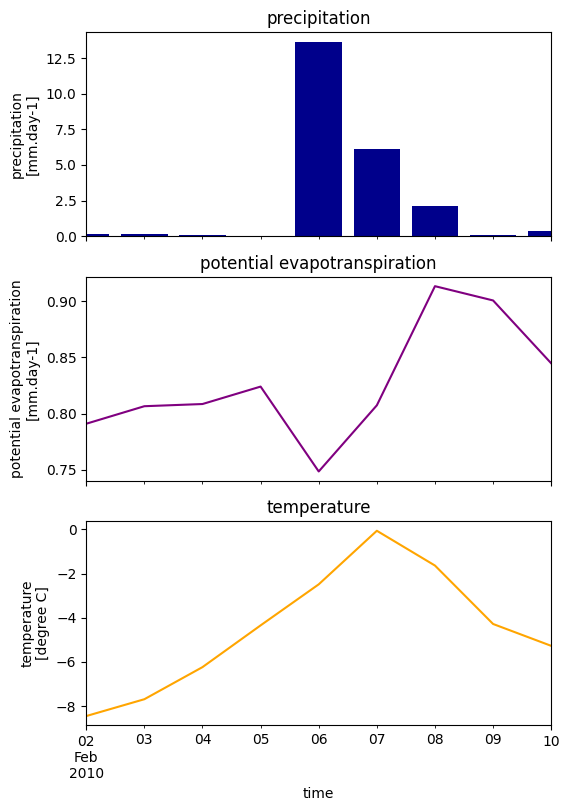

In [6]:
n = len(ds_forcing.data_vars)
kwargs0 = dict(sharex=True, figsize=(6, n * 3))

fig, axes = plt.subplots(n, 1, **kwargs0)
axes = [axes] if n == 1 else axes
for i, name in enumerate(ds_forcing.data_vars):
    df = ds_forcing[name].squeeze().to_series()
    attrs = _ATTRS[name]
    longname = attrs.get("standard_name", "")
    unit = attrs.get("unit", "")
    if name == "precip":
        axes[i].bar(df.index, df.values, facecolor=attrs["color"])
    else:
        df.plot.line(ax=axes[i], x="time", color=attrs["color"])
    axes[i].set_title(longname)
    axes[i].set_ylabel(f"{longname}\n[{unit}]")

# save figure
# fn_out = join(mod.root, "figs", "forcing.png")
# plt.savefig(fn_out, dpi=225, bbox_inches="tight")